# Emilio Leon
## Ejercicio Jugadores Tennis

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder
from sklearn import tree
import numpy as np
from sklearn.preprocessing import OneHotEncoder

In [22]:
df = pd.read_csv("PlayTennis.csv")

In [23]:
df

,outlook,temp,humidity,windy,play
0,sunny,hot,high,False,no
1,sunny,hot,high,True,no
2,overcast,hot,high,False,yes
3,rainy,mild,high,False,yes
4,rainy,cool,normal,False,yes
5,rainy,cool,normal,True,no
6,overcast,cool,normal,True,yes
7,sunny,mild,high,False,no
8,sunny,cool,normal,False,yes
9,rainy,mild,normal,False,yes


In [24]:
encoder = OrdinalEncoder(categories = [
    ["cool", "mild", "hot"], #temp
    ["normal", "high"], # humidity
    [False, True], # Windy
    ["no", "yes"] # Play
])

In [32]:
new_values = encoder.fit_transform(df[["temp", "humidity", "windy", "play"]])
df_values = pd.DataFrame(new_values, columns=["temp", "humidity", "windy", "play"]).astype(int)

In [26]:
encoder_outlook = OneHotEncoder(sparse_output=False)
outlook_codificada = encoder_outlook.fit_transform(df[["outlook"]])
df_outlook = pd.DataFrame(outlook_codificada, columns = encoder_outlook.get_feature_names_out(), index = df.index).astype(int)

In [35]:
df_tenis = df_outlook

In [36]:
df_tenis

,outlook_overcast,outlook_rainy,outlook_sunny
0,0,0,1
1,0,0,1
2,1,0,0
3,0,1,0
4,0,1,0
5,0,1,0
6,1,0,0
7,0,0,1
8,0,0,1
9,0,1,0


In [37]:
df_tenis = pd.concat([df_tenis, df_values], axis=1)

In [38]:
df_tenis

,outlook_overcast,outlook_rainy,outlook_sunny,temp,humidity,windy,play
0,0,0,1,2,1,0,0
1,0,0,1,2,1,1,0
2,1,0,0,2,1,0,1
3,0,1,0,1,1,0,1
4,0,1,0,0,0,0,1
5,0,1,0,0,0,1,0
6,1,0,0,0,0,1,1
7,0,0,1,1,1,0,0
8,0,0,1,0,0,0,1
9,0,1,0,1,0,0,1


In [40]:
y = df_tenis["play"]
X = df_tenis[["outlook_overcast", "outlook_rainy", "outlook_sunny", "temp", "humidity", "windy"]]

In [45]:
clf = tree.DecisionTreeClassifier(criterion="gini")
clf = clf.fit(X,y)

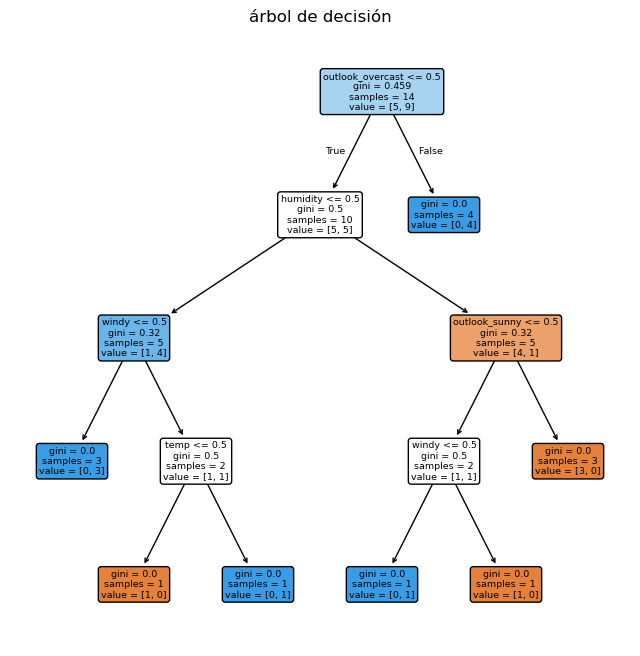

In [46]:
plt.figure(figsize = (8,8))
tree.plot_tree(clf, feature_names=X.columns, filled=True, rounded=True)
plt.title("árbol de decisión")
plt.show()

In [47]:
df_prueba = pd.DataFrame({"outlook_overcast":[0], "outlook_rainy":[1], "outlook_sunny":[0], "temp":[0], "humidity":[2], "windy":[2]})
clf.predict(df_prueba)

array([0])

In [48]:
clf.predict_proba(df_prueba)

array([[1., 0.]])

In [49]:
clf.get_n_leaves()

np.int64(7)